In [9]:
from PySpice.Spice.NgSpice.Shared import NgSpiceCommandError
from PySpice.Spice.NgSpice.Simulation import NgSpiceSharedCircuitSimulator


class NgSpice42CircuitSimulator(NgSpiceSharedCircuitSimulator):
    """ngspice 42 のソルバ起動メッセージによる誤判定を回避する。"""

    def _run(self, analysis_method, *args, **kwargs):
        try:
            return super()._run(analysis_method, *args, **kwargs)
        except NgSpiceCommandError:
            messages = self._ngspice_shared._stderr
            is_solver_banner = messages and all(
                message.strip().startswith("Using ")
                and message.strip().endswith("as Direct Linear Solver")
                for message in messages
            )
            if not is_solver_banner:
                raise
            self._ngspice_shared._error_in_stderr = False
            self.reset_analysis()
            return self._ngspice_shared.plot(
                self, self._ngspice_shared.last_plot
            ).to_analysis()

Using SPARSE 1.3 as Direct Linear Solver


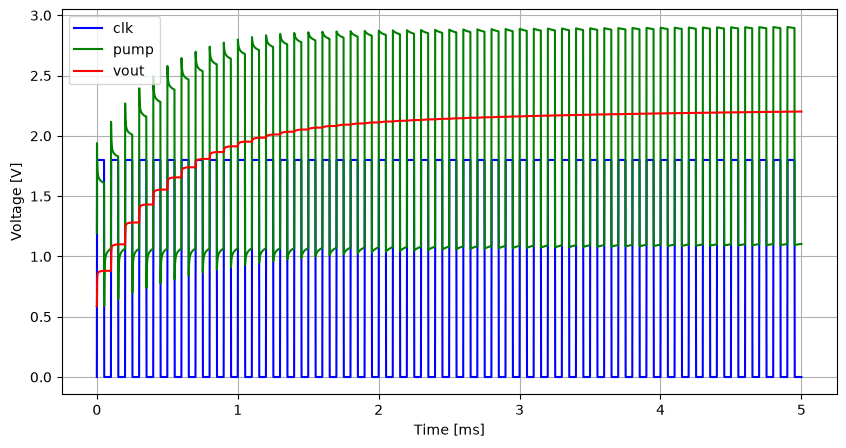

In [23]:
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import u_V, u_uF, u_kOhm, u_ns, u_s, u_kHz
import matplotlib.pyplot as plt

# 電源・クロック条件
VIN = 1.8 @ u_V
FCLK = 10 @ u_kHz
PERIOD = 1 / FCLK

circuit = Circuit("Voltage Doubler Charge Pump")

# 入力電源
circuit.V("in", "vin", circuit.gnd, VIN)

# 0 V <-> 1.8 V のクロック
circuit.PulseVoltageSource(
    "clk", "clk", circuit.gnd,
    initial_value=0 @ u_V,
    pulsed_value=VIN,
    delay_time=0 @ u_s,
    rise_time=1 @ u_us,
    fall_time=1 @ u_us,
    pulse_width=PERIOD / 2,
    period=PERIOD,
)

# ダイオードモデル
# 実回路ではショットキーダイオードやMOSFET同期整流へ置き換える。
circuit.model("DCP", "D", IS=1e-15, N=1.05, RS=0.5)

# Charge pump 本体:
# clk --- Cfly --- pump
# vin --- D1 ----> pump --- D2 ----> vout
circuit.D("1", "vin", "pump", model="DCP")

# 抵抗を入れることで電圧のスパイクを安定させる
circuit.R("fly", "clk", "fly", 1 @ u_Ohm)
circuit.C("fly", "fly", "pump", 1 @ u_uF)
# circuit.C("fly", "clk", "pump", 1 @ u_uF)
circuit.D("2", "pump", "vout", model="DCP")

# 出力平滑コンデンサと負荷
circuit.C("out", "vout", circuit.gnd, 4.7 @ u_uF)
circuit.R("load", "vout", circuit.gnd, 100 @ u_kOhm)

# simulator = circuit.simulator(temperature=25, nominal_temperature=25)
# 過渡解析
simulator = NgSpice42CircuitSimulator(
    circuit,
    temperature=25,
    nominal_temperature=25,
)
analysis = simulator.transient(
    step_time=PERIOD / 200,
    end_time=50 * PERIOD,
)

# 波形表示用
# ｘ軸：時間(time)、ｙ軸：電圧(vin, vout)
time = analysis.time.as_ndarray()*1e3  # ms
clk = analysis["clk"].as_ndarray()
pump = analysis["pump"].as_ndarray()
vout = analysis['vout'].as_ndarray()

plt.figure(figsize=(10, 5))
plt.plot(time, clk, label='clk', color='blue')
plt.plot(time, pump, label='pump', color='green')
plt.plot(time, vout, label='vout', color='red')
plt.xlabel('Time [ms]')
plt.ylabel('Voltage [V]')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
import numpy as np

vout = float(analysis["vout"][-1])

vf_d1 = (analysis["vin"] - analysis["pump"]).as_ndarray()
vf_d2 = (analysis["pump"] - analysis["vout"]).as_ndarray()

# 立上り・立下りの過渡を除くため、解析の後半2周期を対象にする
steady_state = time > (time[-1] - 2 * float(PERIOD * 1e3))

vf_d1_forward = vf_d1[steady_state & (vf_d1 > 0)]
vf_d2_forward = vf_d2[steady_state & (vf_d2 > 0)]

vf_d1_final = np.percentile(vf_d1_forward, 99)
vf_d2_final = np.percentile(vf_d2_forward, 99)
vout_final = float(analysis['vout'][-1])

vout_predicted = 2 * float(VIN) - vf_d1_final - vf_d2_final

print(f"理想的な二倍出力: 2*VIN                        = {2*float(VIN):.3f} V")
print(f"ダイオードによる電圧降下: VF(D1) + VF(D2)      = {vf_d1_final + vf_d2_final:.3f} V")
print(f"予測される出力電圧: 2*VIN - (VF1+VF2)          = {vout_predicted:.3f} V")
print(f"シミュレーションによる出力電圧: Simulated Vout  = {vout_final:.3f} V")
print(f"残差 (RLOAD電流によるIRドロップ等)             = {vout_predicted - vout_final:.3f} V")

理想的な二倍出力: 2*VIN                        = 3.600 V
ダイオードによる電圧降下: VF(D1) + VF(D2)      = 1.410 V
予測される出力電圧: 2*VIN - (VF1+VF2)          = 2.190 V
シミュレーションによる出力電圧: Simulated Vout  = 2.201 V
残差 (RLOAD電流によるIRドロップ等)             = -0.011 V


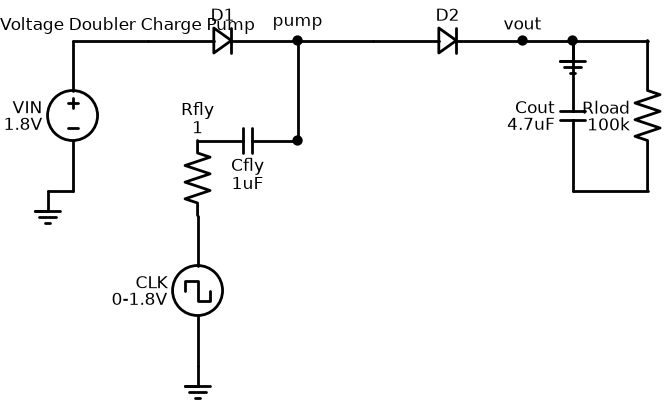

In [1]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    d.config(fontsize=12)
    d += elm.Label().label('Voltage Doubler Charge Pump').at((1, 3.2))

    # VIN 電源
    d += (Vin := elm.SourceV().up().label('VIN\n1.8V'))
    d += elm.Line().right().length(1.5)

    # D1: vin --> pump
    d += (D1 := elm.Diode().right().label('D1', loc='top'))
    pump_node = D1.end
    d += elm.Dot().at(pump_node).label('pump', loc='top')

    # D2: pump --> vout
    d += elm.Line().right().length(1.5).at(pump_node)
    d += (D2 := elm.Diode().right().label('D2', loc='top'))
    vout_node = D2.end
    d += elm.Dot().at(vout_node).label('vout', loc='top')

    # Cout + Rload (負荷)
    d += elm.Line().right().length(1.0).at(vout_node)
    d += elm.Dot()
    d += elm.Capacitor().down().label('Cout\n4.7uF')
    d += elm.Line().right().length(1.5)
    d += elm.Resistor().up().label('Rload\n100k')
    d += elm.Line().left().length(1.5)
    d += elm.Ground()

    # Cfly: pump --- Rfly --- clk
    d += elm.Line().at(pump_node).down().length(2.0)
    d += elm.Dot()
    d += elm.Capacitor().left().length(2.0).label('Cfly\n1uF', loc='bottom').reverse()
    d += elm.Resistor().down().length(1.5).label('Rfly\n1', loc='right')
    d += (Clk := elm.SourceSquare().down().label('CLK\n0-1.8V'))
    d += elm.Ground()

    # VIN の接地
    d.here = Vin.start
    d += elm.Line().left().length(0.5)
    d += elm.Ground()

    d.draw()